# 🧪 Preprocesamiento Integral de Datos - AgroTech

Este notebook consolida y automatiza todo el pipeline de datos: carga, limpieza, ingeniería de variables, corrección de outliers y normalización.

In [1]:
# 1. Instalación de dependencias si es necesario
!pip install -q pandas numpy matplotlib seaborn scikit-learn rich

In [42]:
import pandas as pd
import numpy as np
import re
import os
import glob
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from rich.console import Console
from rich.table import Table
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import MinMaxScaler, KBinsDiscretizer
from scipy.stats import chi2_contingency
console = Console()

## Carga de Archivos Crudos
Buscar todos los archivos `weather_curico_*.csv` y unificarlo.

In [43]:
def load_data(pattern="weather_curico_*.csv"):
    files = sorted(glob.glob(pattern))
    files = [f for f in files if re.search(r'weather_curico_\d+\.csv$', f)]
    if not files:
        raise FileNotFoundError(f"No se encontraron archivos con el patrón: {pattern}")
    
    console.print(f"Cargando archivos: {files}")
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
    
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        #df = df.sort_values('date').reset_index(drop=True)
    
    return df

df = load_data()
df.head()

Cargando archivos: ['weather_curico_2022.csv', 'weather_curico_2023.csv', 'weather_curico_2024.csv', 
'weather_curico_2025.csv']

,date,temperature_2m,relative_humidity_2m,precipitation,rain,cloud_cover,wind_speed_10m,weather_code,pressure_msl,is_day,vapour_pressure_deficit,shortwave_radiation,apparent_temperature,et0_fao_evapotranspiration,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,weather_condition,VPD,water_balance,heat_stress_duration
0,2022-01-01 00:00:00+00:00,22.10,37.180885,0.0,0.0,0.0,15.119999,0.0,1011.1,1.0,1.671907,56.0,19.077402,0.148072,29.85,0.2,Sunny,1.670990,-0.148072,0.0
1,2022-01-01 01:00:00+00:00,20.85,39.726660,0.0,0.0,0.0,16.981165,0.0,1012.0,0.0,1.486150,0.0,17.521273,0.133544,27.80,0.2,Sunny,1.485197,-0.133544,0.0
2,2022-01-01 02:00:00+00:00,19.95,37.859756,0.0,0.0,0.0,20.188908,0.0,1013.2,0.0,1.449567,0.0,15.819109,0.154102,26.15,0.2,Sunny,1.448475,-0.154102,0.0
3,2022-01-01 03:00:00+00:00,17.85,43.313877,0.0,0.0,0.0,17.727943,0.0,1013.9,0.0,1.160038,0.0,14.089218,0.116808,24.70,0.2,Sunny,1.158968,-0.116808,0.0
4,2022-01-01 04:00:00+00:00,16.25,52.081207,0.0,0.0,0.0,13.849477,0.0,1014.3,0.0,0.886202,0.0,13.321316,0.073236,23.35,0.2,Sunny,0.885283,-0.073236,0.0


In [44]:
df.to_csv("weather_curico_all.csv", index=False)

In [45]:
for i in range(len(df.columns)):
    print(df.columns[i])

date
temperature_2m
relative_humidity_2m
precipitation
rain
cloud_cover
wind_speed_10m
weather_code
pressure_msl
is_day
vapour_pressure_deficit
shortwave_radiation
apparent_temperature
et0_fao_evapotranspiration
soil_temperature_0_to_7cm
soil_moisture_0_to_7cm
weather_condition
VPD
water_balance
heat_stress_duration


# Visualización de Variables

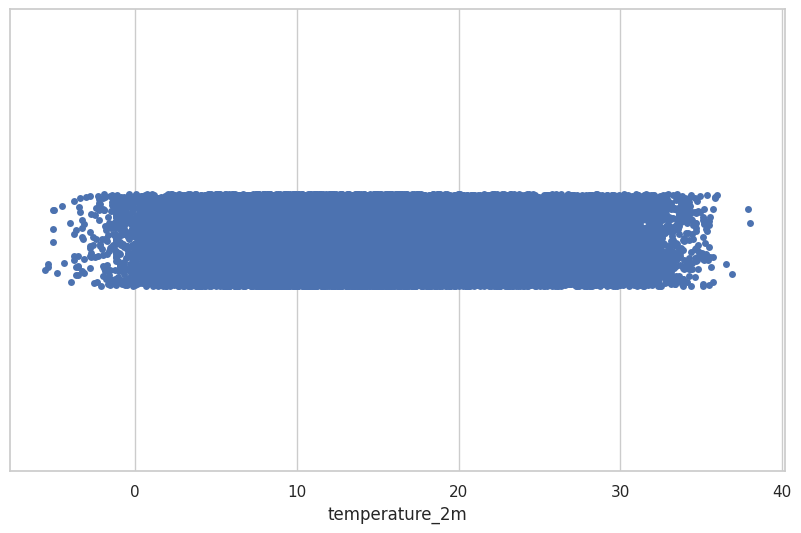

Porcentaje de NaN en temperature_2m: 0.00%


In [46]:
var_check = 'temperature_2m'
plt.figure(figsize=(10, 6))
sns.stripplot(x=var_check, data=df)
plt.xlabel(var_check)
plt.show()
df.loc[df[var_check] > 1500, [var_check]] = np.nan
nan_percentage = df[var_check].isna().sum() / len(df) * 100
print(f"Porcentaje de NaN en {var_check}: {nan_percentage:.2f}%")

Porcentaje de NaN en temperature_2m: 0.00%
Porcentaje de NaN en relative_humidity_2m: 0.00%
Porcentaje de NaN en precipitation: 0.00%
Porcentaje de NaN en rain: 0.00%
Porcentaje de NaN en cloud_cover: 0.00%
Porcentaje de NaN en wind_speed_10m: 0.00%
Porcentaje de NaN en weather_code: 0.00%
Porcentaje de NaN en pressure_msl: 0.00%
Porcentaje de NaN en is_day: 0.00%
Porcentaje de NaN en vapour_pressure_deficit: 0.00%
Porcentaje de NaN en shortwave_radiation: 0.00%
Porcentaje de NaN en apparent_temperature: 0.00%
Porcentaje de NaN en et0_fao_evapotranspiration: 0.00%
Porcentaje de NaN en soil_temperature_0_to_7cm: 0.00%
Porcentaje de NaN en soil_moisture_0_to_7cm: 0.00%
Porcentaje de NaN en VPD: 0.00%
Porcentaje de NaN en water_balance: 0.00%
Porcentaje de NaN en heat_stress_duration: 0.00%


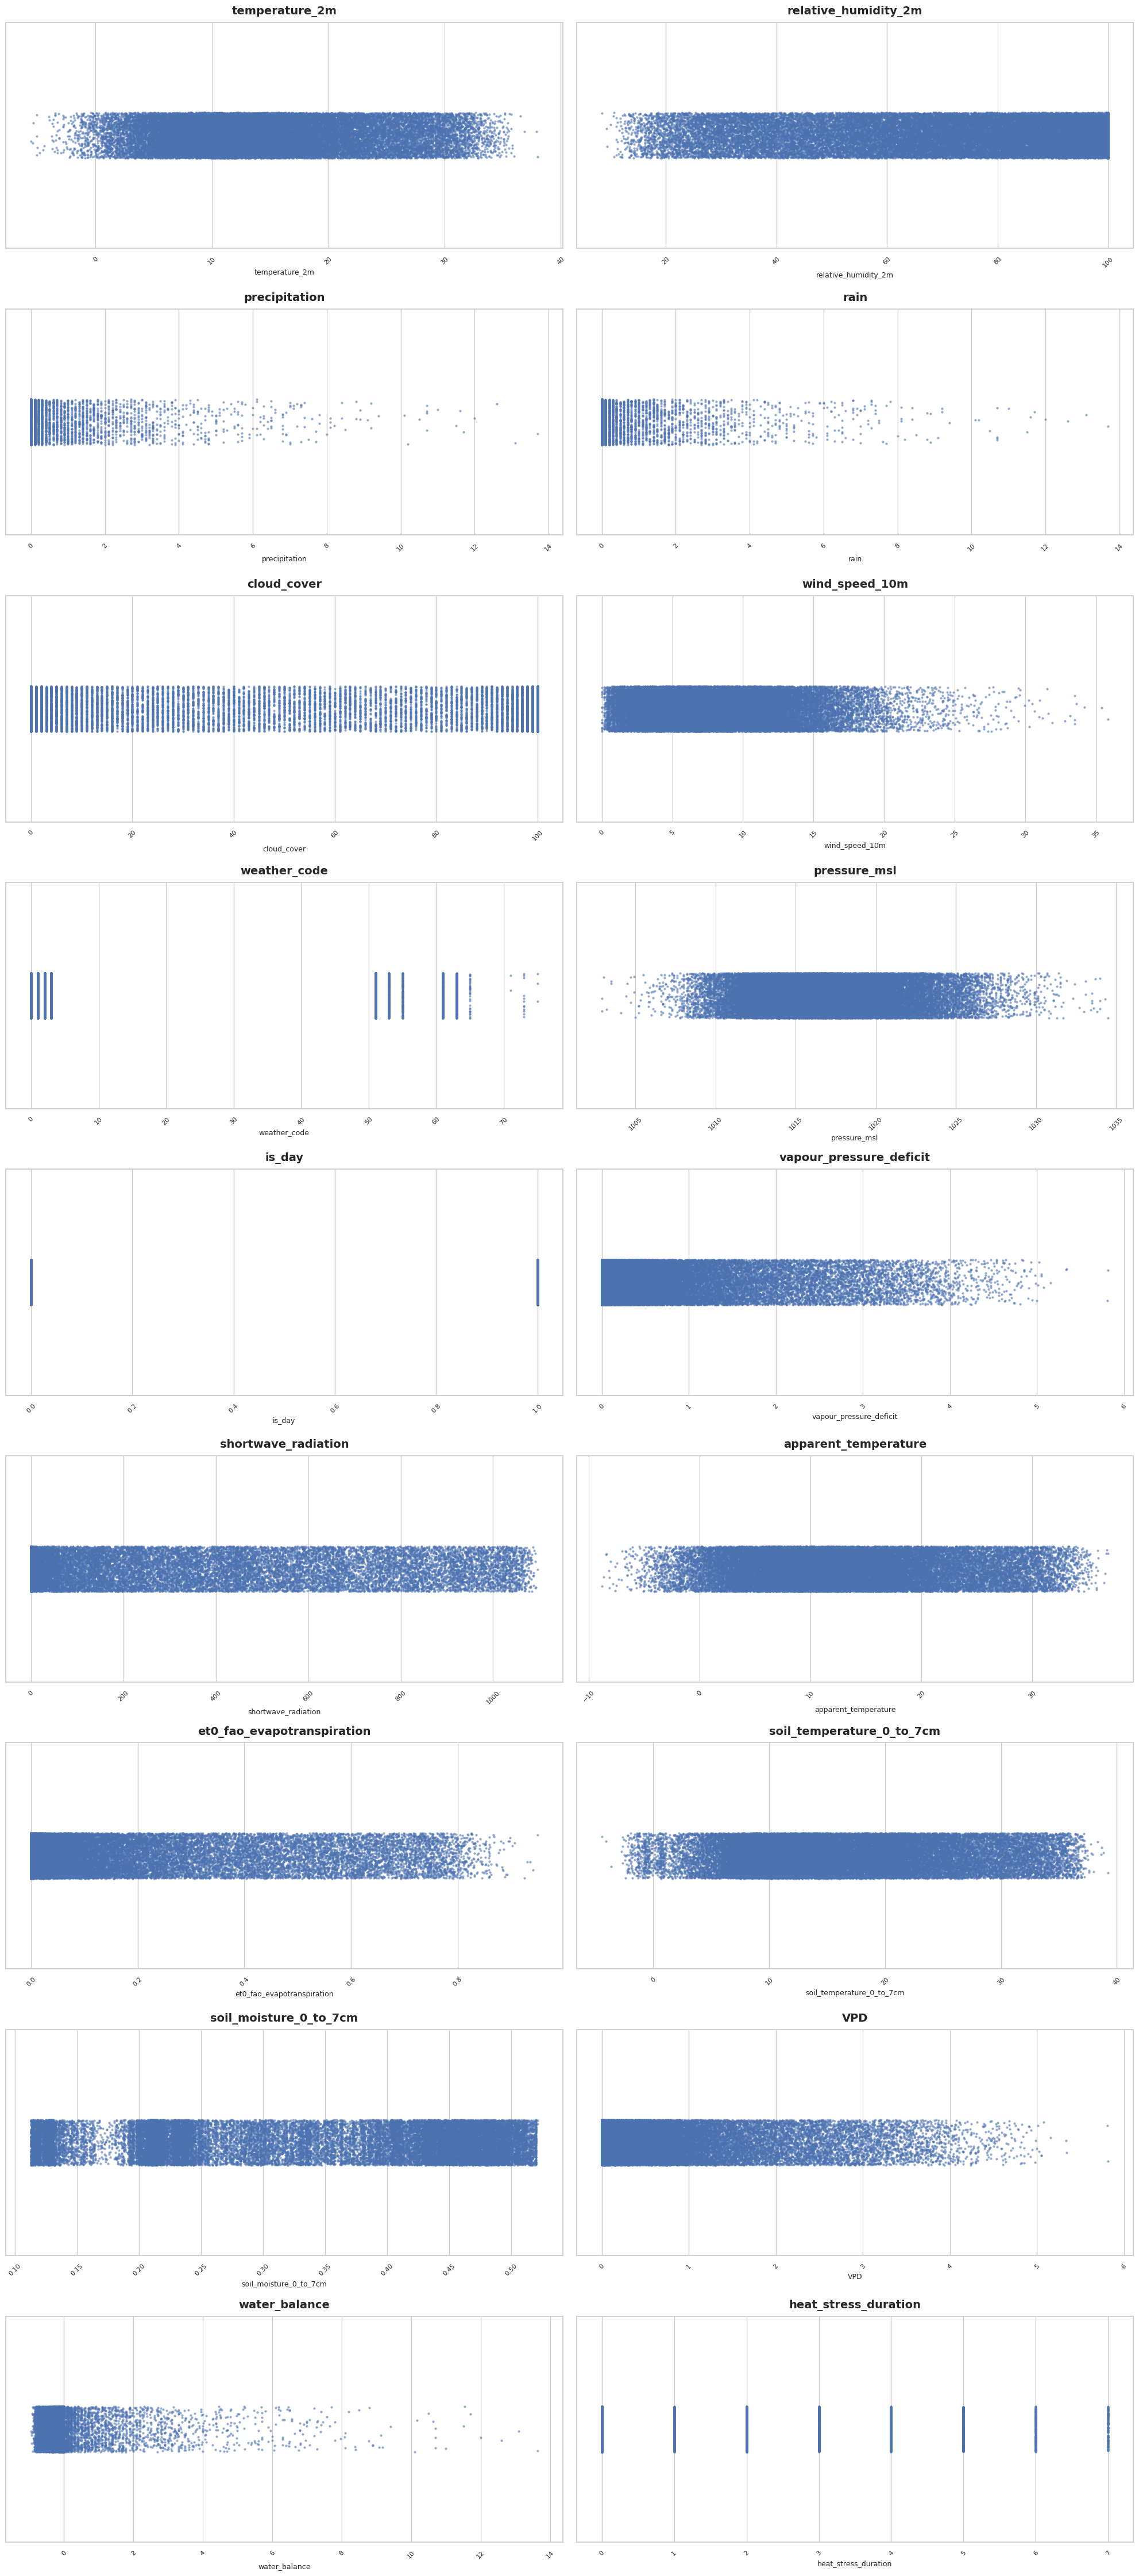

In [47]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Configurar grilla
ncols = 2
nrows = (len(numeric_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5*nrows))
axes = axes.flatten()

for idx, var_check in enumerate(numeric_cols):
    ax = axes[idx]
    ax.set_title(var_check, fontsize=14, fontweight='semibold', pad=10)

    sns.stripplot(x=var_check, data=df, ax=ax, alpha=0.6, size=3)
    ax.set_xlabel(var_check, fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    df.loc[df[var_check] > 1500, var_check] = np.nan
    nan_percentage = df[var_check].isna().sum() / len(df) * 100
    print(f"Porcentaje de NaN en {var_check}: {nan_percentage:.2f}%")
# Ocultar subplots vacíos
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)
plt.tight_layout()
plt.show()

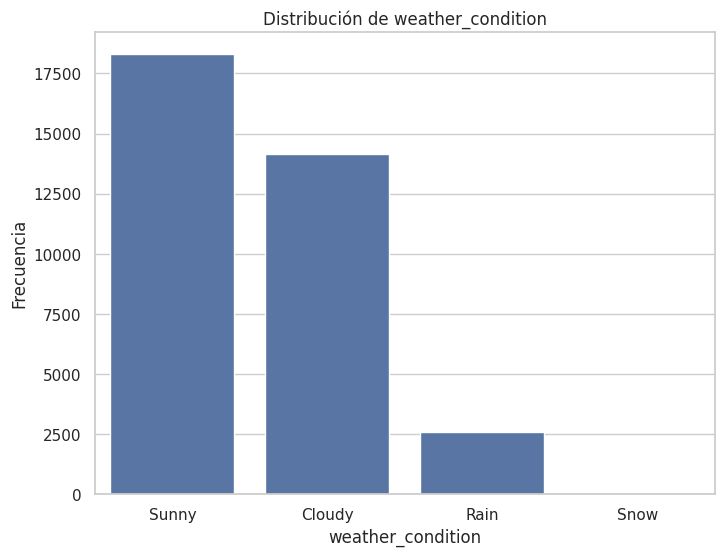

Distribución porcentual:
weather_condition
Sunny     52.215948
Cloudy    40.334816
Rain       7.400753
Snow       0.048483
Name: proportion, dtype: float64


In [48]:
var_check = 'weather_condition'
plt.figure(figsize=(8, 6))
sns.countplot(x=var_check, data=df)
plt.title(f'Distribución de {var_check}')
plt.xlabel(var_check)
plt.ylabel('Frecuencia')
plt.show()
print("Distribución porcentual:")
print(df['weather_condition'].value_counts(normalize=True) * 100)

## Limpieza de datos

### Outliers

In [13]:
def get_outlier_bounds(series, multiplier):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - multiplier * IQR, Q3 + multiplier * IQR

def plot_outlier_comparison(original, cleaned, col, lower, upper):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    sns.boxplot(y=original.dropna(), ax=axes[0], color='lightcoral')
    axes[0].axhline(y=lower, color='red', linestyle='--', label='Límite IQR')
    axes[0].axhline(y=upper, color='red', linestyle='--')
    axes[0].set_title(f'ANTES - {col}')
    axes[0].legend(fontsize=8)

    sns.boxplot(y=cleaned, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'DESPUÉS - {col}')

    plt.suptitle(f'Tratamiento de Outliers: {col}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [28]:
def handle_outliers(df, columns, method='median', multiplier=3, show_plots=True):
    df_clean = df.copy()
    report_data = []

    for col in columns:
        if col not in df_clean.columns or df_clean[col].isna().all(): continue

        lower, upper = get_outlier_bounds(df_clean[col], multiplier)
        mask = (df_clean[col] < lower) | (df_clean[col] > upper)
        n_outliers = mask.sum()

        if n_outliers > 0:
            replacement = df_clean[col].median() if method == 'median' else df_clean[col].mean()
            df_clean.loc[mask, col] = replacement

            if show_plots:
                plot_outlier_comparison(df[col], df_clean[col], col, lower, upper)

            report_data.append({
                'Columna': col,
                'Outliers': n_outliers,
                '% Dataset': f"{(n_outliers/len(df))*100:.2f}%",
                'Límites': f'[{lower:.2f}, {upper:.2f}]'
            })
            print(f"{col}: corregidos {n_outliers} outliers")

    if report_data:
        display(pd.DataFrame(report_data).sort_values('Outliers', ascending=False))

    return df_clean, report_data

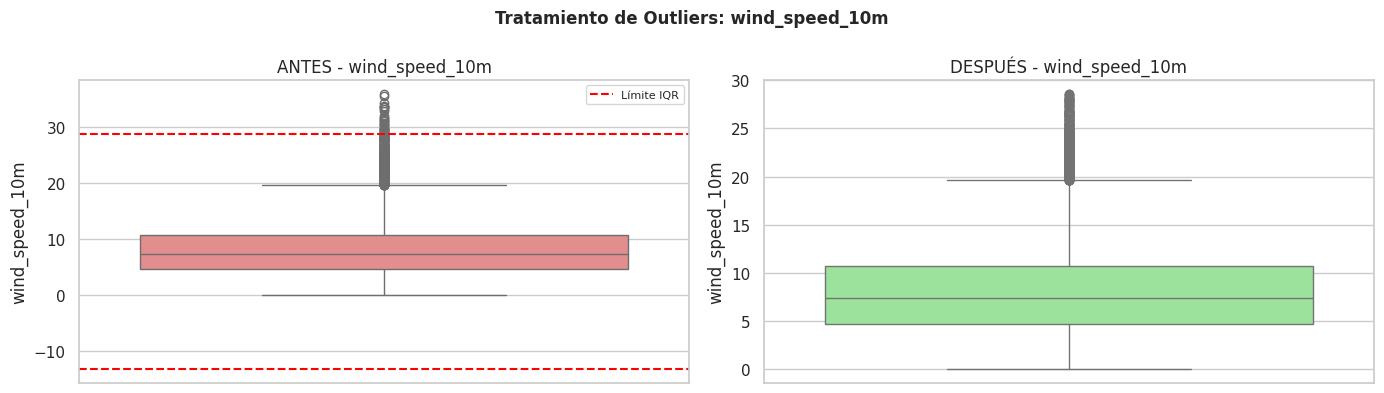

wind_speed_10m: corregidos 32 outliers


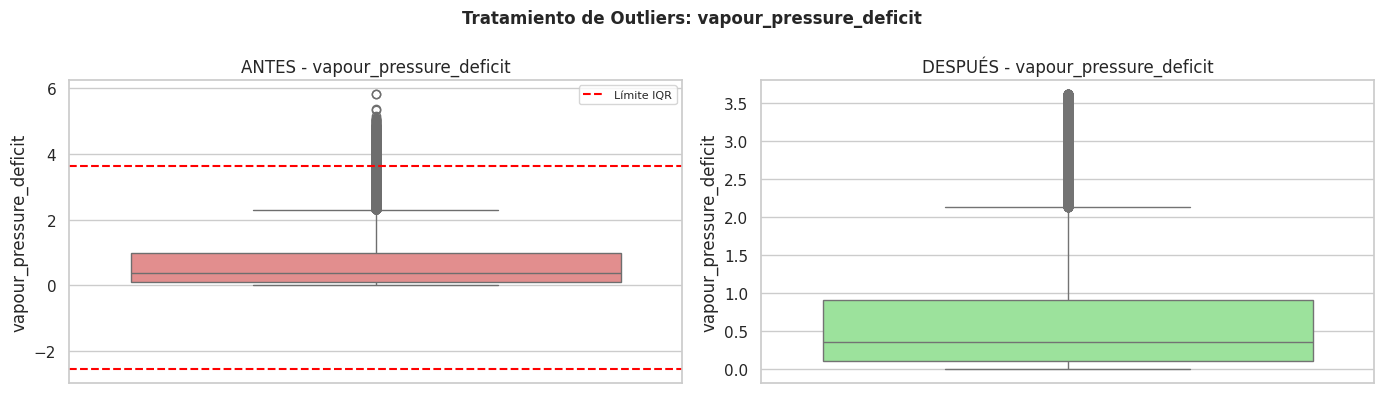

vapour_pressure_deficit: corregidos 534 outliers


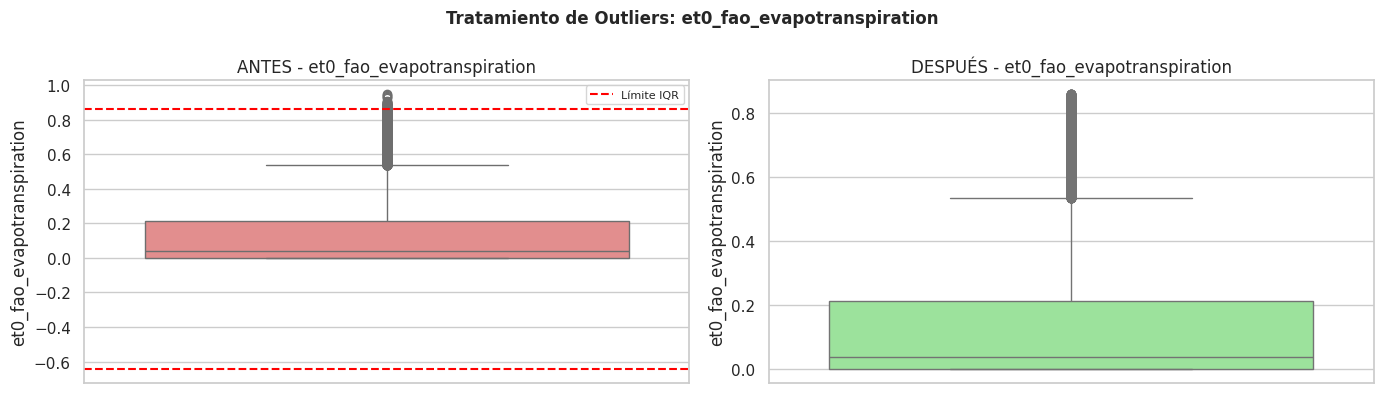

et0_fao_evapotranspiration: corregidos 37 outliers


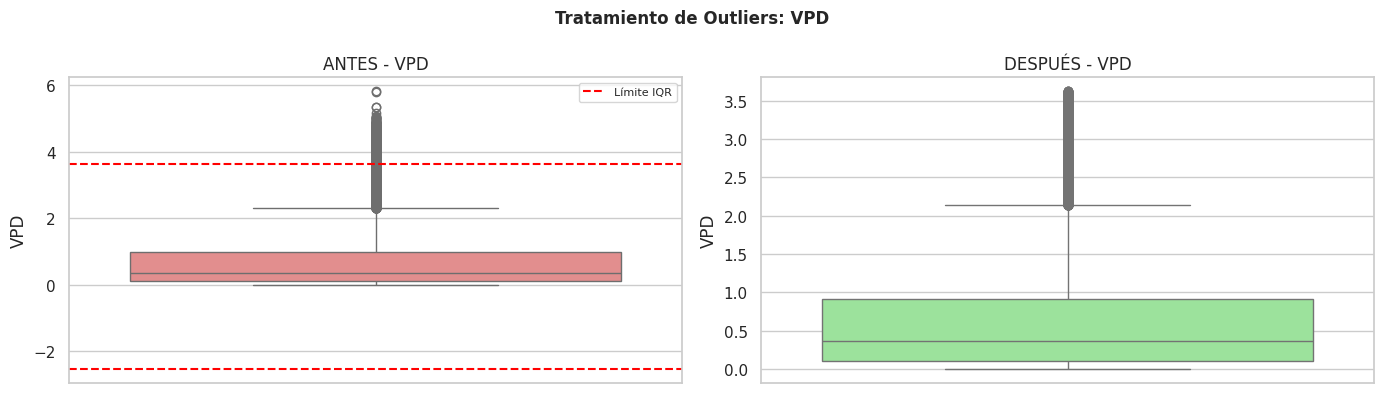

VPD: corregidos 535 outliers


,Columna,Outliers,% Dataset,Límites
3,VPD,535,1.53%,"[-2.54, 3.63]"
1,vapour_pressure_deficit,534,1.52%,"[-2.54, 3.63]"
2,et0_fao_evapotranspiration,37,0.11%,"[-0.64, 0.86]"
0,wind_speed_10m,32,0.09%,"[-13.18, 28.62]"


In [49]:
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in ['date', 'is_day', 'heat_stress_duration', 'weather_code', 'precipitation', 'rain', 'water_balance']]

df_clean, outlier_report = handle_outliers(df, num_cols, method='median', multiplier=3,show_plots=True)

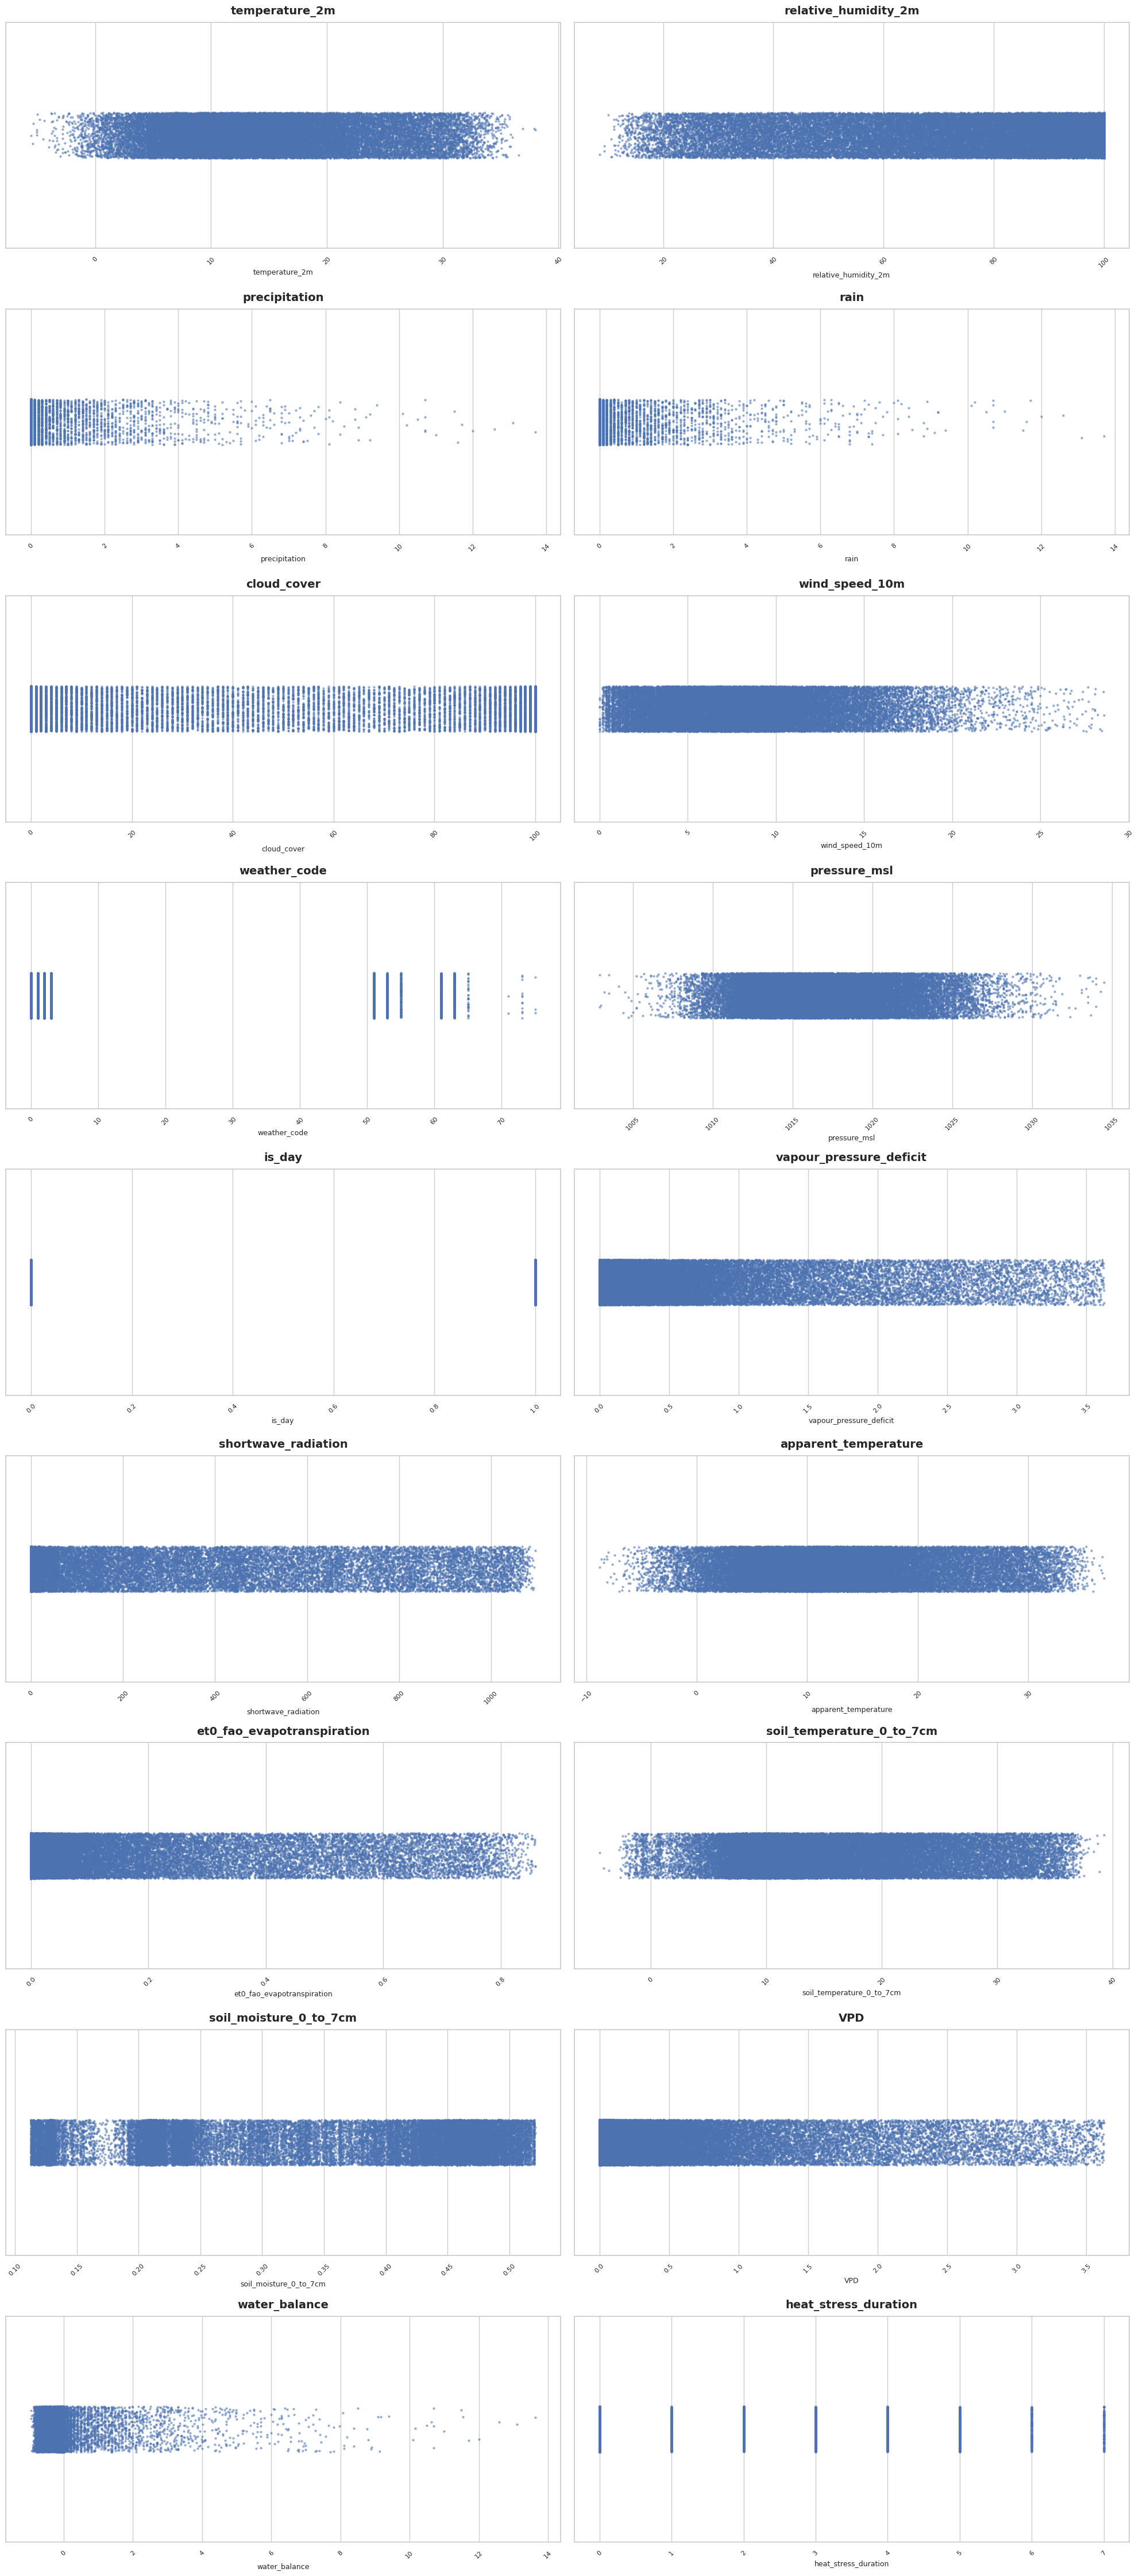

In [50]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
# Configurar grilla
ncols = 2
nrows = (len(numeric_cols) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5*nrows))
axes = axes.flatten()

for idx, var_check in enumerate(numeric_cols):
    ax = axes[idx]
    ax.set_title(var_check, fontsize=14, fontweight='semibold', pad=10)

    sns.stripplot(x=var_check, data=df_clean, ax=ax, alpha=0.6, size=3)
    ax.set_xlabel(var_check, fontsize=9)
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)

    df_clean.loc[df[var_check] > 1500, var_check] = np.nan
# Ocultar subplots vacíos
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)
plt.tight_layout()
plt.show()

### Normalización
Escalamos los datos y generamos el dataset consolidado y las carpetas de entrenamiento.

In [51]:
df_clean.head()

,date,temperature_2m,relative_humidity_2m,precipitation,rain,cloud_cover,wind_speed_10m,weather_code,pressure_msl,is_day,vapour_pressure_deficit,shortwave_radiation,apparent_temperature,et0_fao_evapotranspiration,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,weather_condition,VPD,water_balance,heat_stress_duration
0,2022-01-01 00:00:00+00:00,22.10,37.180885,0.0,0.0,0.0,15.119999,0.0,1011.1,1.0,1.671907,56.0,19.077402,0.148072,29.85,0.2,Sunny,1.670990,-0.148072,0.0
1,2022-01-01 01:00:00+00:00,20.85,39.726660,0.0,0.0,0.0,16.981165,0.0,1012.0,0.0,1.486150,0.0,17.521273,0.133544,27.80,0.2,Sunny,1.485197,-0.133544,0.0
2,2022-01-01 02:00:00+00:00,19.95,37.859756,0.0,0.0,0.0,20.188908,0.0,1013.2,0.0,1.449567,0.0,15.819109,0.154102,26.15,0.2,Sunny,1.448475,-0.154102,0.0
3,2022-01-01 03:00:00+00:00,17.85,43.313877,0.0,0.0,0.0,17.727943,0.0,1013.9,0.0,1.160038,0.0,14.089218,0.116808,24.70,0.2,Sunny,1.158968,-0.116808,0.0
4,2022-01-01 04:00:00+00:00,16.25,52.081207,0.0,0.0,0.0,13.849477,0.0,1014.3,0.0,0.886202,0.0,13.321316,0.073236,23.35,0.2,Sunny,0.885283,-0.073236,0.0


In [52]:
variables_to_scale = ['temperature_2m', 'relative_humidity_2m', 'precipitation',
                      'rain', 'cloud_cover', 'wind_speed_10m',
                      'pressure_msl', 'vapour_pressure_deficit', 'shortwave_radiation',
                      'soil_temperature_0_to_7cm', 'soil_moisture_0_to_7cm', 'VPD',
                      'water_balance', 'heat_stress_duration']

for var in variables_to_scale:
    scaler = MinMaxScaler()
    df_clean[var] = scaler.fit_transform(df_clean[[var]])

df_clean

,date,temperature_2m,relative_humidity_2m,precipitation,rain,cloud_cover,wind_speed_10m,weather_code,pressure_msl,is_day,vapour_pressure_deficit,shortwave_radiation,apparent_temperature,et0_fao_evapotranspiration,soil_temperature_0_to_7cm,soil_moisture_0_to_7cm,weather_condition,VPD,water_balance,heat_stress_duration
0,2022-01-01 00:00:00+00:00,0.634902,0.313877,0.0,0.0,0.0,0.528626,0.0,0.259494,1.0,0.461105,0.051095,19.077402,0.148072,0.784897,0.213235,Sunny,0.460977,0.054970,0.000000
1,2022-01-01 01:00:00+00:00,0.606200,0.341682,0.0,0.0,0.0,0.593696,0.0,0.287975,0.0,0.409874,0.000000,17.521273,0.133544,0.737986,0.213235,Sunny,0.409722,0.055967,0.000000
2,2022-01-01 02:00:00+00:00,0.585534,0.321291,0.0,0.0,0.0,0.705846,0.0,0.325949,0.0,0.399784,0.000000,15.819109,0.154102,0.700229,0.213235,Sunny,0.399592,0.054557,0.000000
3,2022-01-01 03:00:00+00:00,0.537313,0.380862,0.0,0.0,0.0,0.619805,0.0,0.348101,0.0,0.319934,0.000000,14.089218,0.116808,0.667048,0.213235,Sunny,0.319725,0.057114,0.000000
4,2022-01-01 04:00:00+00:00,0.500574,0.476621,0.0,0.0,0.0,0.484206,0.0,0.360759,0.0,0.244411,0.000000,13.321316,0.073236,0.636156,0.213235,Sunny,0.244224,0.060102,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2025-12-31 19:00:00+00:00,0.933410,0.121350,0.0,0.0,0.0,0.213597,0.0,0.250000,1.0,0.100444,0.892336,36.449640,0.776743,0.986270,0.009804,Sunny,0.100341,0.011863,0.857143
35060,2025-12-31 20:00:00+00:00,0.939150,0.121287,0.0,0.0,0.0,0.344289,0.0,0.234177,1.0,0.100444,0.770073,35.256462,0.713698,1.000000,0.009804,Sunny,0.100341,0.016186,0.857143
35061,2025-12-31 21:00:00+00:00,0.904707,0.175831,0.0,0.0,0.0,0.529973,0.0,0.224684,1.0,0.100444,0.605839,32.484528,0.615473,0.990847,0.009804,Sunny,0.100341,0.022921,0.857143
35062,2025-12-31 22:00:00+00:00,0.849598,0.204604,0.0,0.0,0.0,0.535511,0.0,0.237342,1.0,0.925601,0.412409,29.309937,0.450011,0.959954,0.009804,Sunny,0.925911,0.034267,0.714286


In [53]:
def export_data(df):
    df = df_clean.copy()
    # Normalización
    scaler = StandardScaler()
    num_cols = df.select_dtypes(include=[np.number]).columns
    scale_cols = [c for c in num_cols if c != 'is_day']
    df[scale_cols] = scaler.fit_transform(df[scale_cols])

    df.to_csv("weather_curico_preprocessed.csv", index=False)

    split = int(len(df) * 0.7)
    sets = {'train': df.iloc[:split], 'test': df.iloc[split:]}
    
    for name, dataset in sets.items():
        if os.path.exists(name): shutil.rmtree(name) # Limpiar carpetas viejas
        os.makedirs(name)
        
        for cls in dataset['weather_condition'].unique():
            path = os.path.join(name, str(cls).lower().replace(" ", "_"))
            os.makedirs(path, exist_ok=True)
            dataset[dataset['weather_condition'] == cls].to_csv(os.path.join(path, "data.csv"), index=False)
            
    print("Proceso finalizado")
    print("Dataset consolidado y carpetas /train y /test generadas correctamente.")

export_data(df_clean)

Proceso finalizado
Dataset consolidado y carpetas /train y /test generadas correctamente.
